# Otras posibilidades: prediciendo de otras formas

* Introducir otros features
* Predecir teniendo en cuenta los retornos acumulados de Lopez de Prado
* Cambiar la target de precio exacto a subida o bajada en el período con la triple barrera
* Cambiar la target a volatilidad en vez de retorno
* GAP para evitar information leakage

# 0. Importaciones

In [ ]:
import numpy as np
import pandas as pd
import re
import yfinance as yf
import warnings
from typing import Any, Callable, Dict, List, Optional, Tuple
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler

import math
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

warnings.simplefilter(action="ignore", category=FutureWarning)

# Reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Carga de datos
start_date = '1945-01-01'
tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD',
                   'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM',
                   'MO', 'MRK', 'MSI', 'PG', 'XOM']

precios_close = yf.download(tickers_validos, start=start_date,
                            auto_adjust=True, progress=False)['Close']
precios_close.dropna(axis=1, inplace=True)

returns = np.log(precios_close).diff().dropna()
print(f"Returns: {returns.shape}")

Returns: (16200, 23)


In [9]:
def split_triple(X, y, test_size=0.1, val_size=0.05):
    """Test cronológico, train/val aleatorio (indicación del profesor).."""
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size,  
        shuffle=True, random_state=RANDOM_SEED
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

In [10]:
from tensorflow.keras.callbacks import Callback
from sklearn.preprocessing import StandardScaler

class MAERealCallback(Callback):
    """
    Calcula MAE en escala original tras des-normalizar con scaler_y.
    Necesario porque el modelo entrena con datos normalizados y el loss
    interno de Keras está en escala normalizada.
    """
    def __init__(self, X_train_n, y_train_real, X_val_n, y_val_real, scaler_y):
        super().__init__()
        self.X_train_n = X_train_n
        self.y_train_real = y_train_real
        self.X_val_n = X_val_n
        self.y_val_real = y_val_real
        self.scaler_y = scaler_y
        self.mae_train = []
        self.mae_val = []

    def on_epoch_end(self, epoch, logs=None):
        pred_train = self.scaler_y.inverse_transform(
            self.model.predict(self.X_train_n, verbose=0))
        pred_val = self.scaler_y.inverse_transform(
            self.model.predict(self.X_val_n, verbose=0))

        self.mae_train.append(np.mean(np.abs(self.y_train_real - pred_train)))
        self.mae_val.append(np.mean(np.abs(self.y_val_real - pred_val)))

# 1. Retornos acumulados de Lopez de Prado

Introducimos la diferenciación fraccional como instrumento para mejorar la obtención del target retorno simple. No aplicamos diferenciación fraccional al target, solo lo usamos para ayudar a la red a predecir.

El modelo no necesita ver directamente la variable predecir, sino una representación de ella que sea más estable, más informativa o más predecible, y de ahí la gracia de la diferenciación fraccional.

In [2]:
def get_fractional_weights(
    d: float
) -> np.ndarray:
    """
    Calcula los pesos para fractional differentiation.
    Introduce d (orden de diferenciación) y devuelve un array de pesos.
    """

    weights = [1.0]
    threshold= 1e-5
    k = 1

    while True:
        w = -weights[-1] * (d - k + 1) / k

        if abs(w) < threshold:
            break

        weights.append(w)
        k += 1

    return np.array(weights[::-1]).reshape(-1, 1)

In [5]:
def fractional_difference(
    series: pd.Series,
    d: float,
) -> pd.Series:
    """
    Aplica fractional differentiation a una serie temporal.
    Se debe introducir la serie y el orden de diferenciación d.
    """

    weights = get_fractional_weights(d)

    width = len(weights)

    output = pd.Series(index=series.index, dtype=np.float64)

    for i in range(width - 1, len(series)):
        window = series.iloc[i - width + 1:i + 1]

        output.iloc[i] = np.dot(
            weights.T,
            window.values
        )[0]

    return output.dropna()

In [6]:
def fractional_difference_df(
    prices: pd.DataFrame,
    d: float,
) -> pd.DataFrame:
    """
    Aplica fractional differentiation a cada activo usando log-precios.
    """

    log_prices = np.log(prices)

    fracdiff_data = pd.DataFrame(index=log_prices.index)

    for col in log_prices.columns:
        fracdiff_data[col] = fractional_difference(
            series=log_prices[col],
            d=d,
        )

    return fracdiff_data.dropna(how="any")

Creamos las ventanas de la target

In [29]:
def create_time_series_data_xy(
    features: pd.DataFrame,
    targets: pd.DataFrame,
    input_window_size: int,
    output_window_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Crea ventanas supervisadas:
    X = features pasadas
    y = media de retornos futuros reales.

    Esto permite meter feature y target que se calculen de formas diferentes.
    """

    x_values = features.values
    y_values = targets.values

    X, y = [], []

    max_i = len(features) - input_window_size - output_window_size + 1

    for i in range(max_i):
        input_seq = x_values[i:i + input_window_size]

        output_seq = y_values[
            i + input_window_size:
            i + input_window_size + output_window_size
        ]

        X.append(input_seq)
        y.append(np.mean(output_seq, axis=0))

    return np.array(X), np.array(y)

Preparamos el data

In [30]:
def prepare_cnn_data(
    features: pd.DataFrame,
    targets: pd.DataFrame,
    input_window: int,
    output_window: int,
    scale_y: bool = True,
) -> Dict[str, Any]:
    """Crea ventanas, divide train/val/test y normaliza sin leakage."""

    common_index = features.index.intersection(targets.index)
    features = features.loc[common_index].dropna()
    targets = targets.loc[features.index].dropna()

    common_index = features.index.intersection(targets.index)
    features = features.loc[common_index]
    targets = targets.loc[common_index]

    X, y = create_time_series_data_xy(
        features=features,
        targets=targets,
        input_window_size=input_window,
        output_window_size=output_window,
    )

    X_train, X_val, X_test, y_train, y_val, y_test = split_triple(X, y)

    scaler_X = RobustScaler()
    scaler_X.fit(X_train.reshape(-1, X_train.shape[-1]))

    X_train_n = scaler_X.transform(
        X_train.reshape(-1, X_train.shape[-1])
    ).reshape(X_train.shape)

    X_val_n = scaler_X.transform(
        X_val.reshape(-1, X_val.shape[-1])
    ).reshape(X_val.shape)

    X_test_n = scaler_X.transform(
        X_test.reshape(-1, X_test.shape[-1])
    ).reshape(X_test.shape)

    scaler_y = None

    if scale_y:
        scaler_y = RobustScaler()
        scaler_y.fit(y_train)

        y_train_n = scaler_y.transform(y_train)
        y_val_n = scaler_y.transform(y_val)
        y_test_n = scaler_y.transform(y_test)
    else:
        y_train_n = y_train
        y_val_n = y_val
        y_test_n = y_test

    return {
        "X_train_n": X_train_n,
        "X_val_n": X_val_n,
        "X_test_n": X_test_n,
        "y_train_n": y_train_n,
        "y_val_n": y_val_n,
        "y_test_n": y_test_n,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
    }

Ejecutamos modelo generalista avanzado

In [31]:
# Modelo base CNN con hiperparámetros modificables para experimentar.

def cnn_base(
    input_window: int,
    n_features: int,
    n_outputs: int,
    kernel_size: Optional[int] = None,
    filters_1: int = 16,
    filters_2: int = 32,
    dropout_rate: float = 0.1,
    dense_units: int = 12,
    learning_rate: float = 0.001,
) -> tf.keras.Model:
    """Construye una CNN base modificable.
        - kernel_size: Tamaño del kernel para las capas Conv1D. Si es None, se calcula como ceil(input_window / 3).
        - filters_1: Número de filtros en la primera capa Conv1D.
        - filters_2: Número de filtros en la segunda capa Conv1D.
        - dropout_rate: Tasa de dropout para las capas de Dropout.
        - dense_units: Número de unidades en la capa densa antes de la salida.
        - learning_rate: Tasa de aprendizaje para el optimizador Adam.
    """

    if kernel_size is None:
        kernel_size = math.ceil(input_window / 3)

    kernel_size = max(1, min(kernel_size, input_window))

    modelo = models.Sequential(
        [
            layers.Input(shape=(input_window, n_features)),

            layers.Conv1D(
                filters=filters_1,
                kernel_size=kernel_size,
                padding="same",
                activation="relu",
            ),

            layers.Conv1D(
                filters=filters_2,
                kernel_size=kernel_size,
                padding="same",
                activation="relu",
            ),

            layers.Dropout(dropout_rate),

            layers.GlobalAveragePooling1D(),

            layers.Dense(dense_units, activation="relu"),
            layers.Dropout(dropout_rate),

            layers.Dense(n_outputs),
        ]
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    modelo.compile(optimizer=optimizer, loss="mae")

    return modelo

In [38]:
def run_cnn_grid(
    features: pd.DataFrame,
    targets: pd.DataFrame,
    input_windows: List[int],
    output_windows: List[int],
    results_dir: str = "results/cnn_grid",
    epochs: int = 20,
    filters_1: int = 16,
    filters_2: int = 32,
    dropout_rate: float = 0.1,
    batch_size: int = 32,
    kernel_size_fn: Optional[Callable[[int], int]] = None,
    fixed_kernel_size: Optional[int] = None,
    verbose: int = 1,
    random_seed: int = 42,
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Any]]]:

    tf.keras.utils.set_random_seed(random_seed)

    results_path = Path(results_dir)
    results_path.mkdir(parents=True, exist_ok=True)

    all_results = {}
    all_metrics = []

    for input_window in input_windows:
        for output_window in output_windows:

            experiment_name = f"cnn_iw_{input_window}_ow_{output_window}"
            experiment_dir = results_path / experiment_name
            experiment_dir.mkdir(parents=True, exist_ok=True)

            if fixed_kernel_size is not None:
                kernel_size = fixed_kernel_size
            elif kernel_size_fn is not None:
                kernel_size = kernel_size_fn(input_window)
            else:
                kernel_size = math.ceil(input_window / 3)

            data = prepare_cnn_data(
                features=features,
                targets=targets,
                input_window=input_window,
                output_window=output_window,
            )

            model = cnn_base(
                input_window=input_window,
                filters_1=filters_1,
                filters_2=filters_2,
                dropout_rate=dropout_rate,
                n_features=data["X_train_n"].shape[2],
                n_outputs=data["y_train_n"].shape[1],
                kernel_size=kernel_size,
            )

            mae_real_cb = MAERealCallback(
                data["X_train_n"],
                data["y_train"],
                data["X_val_n"],
                data["y_val"],
                data["scaler_y"],
            )

            best_model_path = experiment_dir / "best_model.keras"

            checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
                filepath=best_model_path,
                monitor="val_loss",
                save_best_only=True,
                mode="min",
                verbose=0,
            )

            print(
                f"Entrenando {experiment_name} | "
                f"kernel={kernel_size} | "
                f"params={model.count_params():,}"
            )

            reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=10,
            min_lr=1e-7,
            verbose=1,
            )

            early_stopping = tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=40,
                restore_best_weights=True,
                verbose=1,
            )

            checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
                filepath=best_model_path,
                monitor="val_loss",
                save_best_only=True,
                mode="min",
                verbose=0,
            )


            history = model.fit(
                data["X_train_n"],
                data["y_train_n"],
                epochs=epochs,
                batch_size=batch_size,
                validation_data=(data["X_val_n"], data["y_val_n"]),
                callbacks=[mae_real_cb, checkpoint_cb, reduce_lr, early_stopping],
                verbose=verbose,
                shuffle=True,
            )

            best_model = tf.keras.models.load_model(best_model_path)

            y_train_pred = data["scaler_y"].inverse_transform(
                best_model.predict(data["X_train_n"], verbose=0)
            )
            y_val_pred = data["scaler_y"].inverse_transform(
                best_model.predict(data["X_val_n"], verbose=0)
            )
            y_test_pred = data["scaler_y"].inverse_transform(
                best_model.predict(data["X_test_n"], verbose=0)
            )

            n_epochs_run = len(history.history["loss"])

            history_df = pd.DataFrame(
                {
                    "epoch": np.arange(1, n_epochs_run + 1),
                    "loss_train_norm": history.history["loss"],
                    "loss_val_norm": history.history["val_loss"],
                    "mae_train_real": mae_real_cb.mae_train,
                    "mae_val_real": mae_real_cb.mae_val,
                }
            )

            metrics = {
                "experiment_name": experiment_name,
                "input_window": input_window,
                "output_window": output_window,
                "kernel_size": kernel_size,
                "epochs": n_epochs_run,
                "batch_size": batch_size,
                "n_params": int(best_model.count_params()),
                "best_epoch": int(history_df["mae_val_real"].idxmin() + 1),
                "best_val_mae_real": float(history_df["mae_val_real"].min()),
                "final_val_mae_real": float(history_df["mae_val_real"].iloc[-1]),
                "train_mae_real": float(
                    mean_absolute_error(data["y_train"], y_train_pred)
                ),
                "val_mae_real": float(
                    mean_absolute_error(data["y_val"], y_val_pred)
                ),
                "test_mae_real": float(
                    mean_absolute_error(data["y_test"], y_test_pred)
                ),
            }

            history_df.to_csv(experiment_dir / "history.csv", index=False)
            pd.DataFrame([metrics]).to_csv(
                experiment_dir / "metrics.csv",
                index=False,
            )

            np.save(experiment_dir / "y_train_true.npy", data["y_train"])
            np.save(experiment_dir / "y_val_true.npy", data["y_val"])
            np.save(experiment_dir / "y_test_true.npy", data["y_test"])
            np.save(experiment_dir / "y_train_pred.npy", y_train_pred)
            np.save(experiment_dir / "y_val_pred.npy", y_val_pred)
            np.save(experiment_dir / "y_test_pred.npy", y_test_pred)

            plt.figure(figsize=(8, 5))
            plt.plot(
                history_df["epoch"],
                history_df["mae_train_real"],
                label="train",
            )
            plt.plot(
                history_df["epoch"],
                history_df["mae_val_real"],
                label="val",
            )
            plt.xlabel("Epoch")
            plt.ylabel("MAE real")
            plt.title(
                f"CNN MAE real | IW={input_window}, "
                f"OW={output_window}, kernel={kernel_size}"
            )
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(experiment_dir / "mae_real.png", dpi=150)
            plt.close()

            key = f"iw_{input_window}_ow_{output_window}"

            all_results[key] = {
                "model": best_model,
                "history": history_df,
                "metrics": metrics,
                "experiment_dir": experiment_dir,
            }

            all_metrics.append(metrics)

    summary_df = pd.DataFrame(all_metrics)
    summary_df = summary_df.sort_values("best_val_mae_real").reset_index(drop=True)
    summary_df.to_csv(results_path / "summary_all_experiments.csv", index=False)

    return summary_df, all_results

In [33]:
def plot_cnn_grid_losses(
    results: Dict[str, Dict[str, Any]],
    input_windows: List[int],
    output_windows: List[int],
    save_path: Optional[str] = None,
) -> None:

    fig, axes = plt.subplots(
        len(input_windows),
        len(output_windows),
        figsize=(5 * len(output_windows), 3.5 * len(input_windows)),
    )

    for i, input_window in enumerate(input_windows):
        for j, output_window in enumerate(output_windows):
            ax = axes[i, j]
            key = f"iw_{input_window}_ow_{output_window}"

            history_df = results[key]["history"]
            metrics = results[key]["metrics"]

            ax.plot(history_df["epoch"], history_df["mae_train_real"], label="train")
            ax.plot(history_df["epoch"], history_df["mae_val_real"], label="val")

            ax.set_title(
                f"IW={input_window}, OW={output_window} | "
                f"best={metrics['best_val_mae_real']:.5f}"
            )
            ax.set_xlabel("Epoch")
            ax.set_ylabel("MAE real")
            ax.grid(True)
            ax.legend()

    fig.suptitle("CNN base - MAE real por combinación", fontsize=16)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)

    plt.show()

Utilizamos las funciones

In [36]:
fracdiff_features = fractional_difference_df(
    prices=precios_close,
    d=0.4,
)

log_returns = np.log(precios_close).diff().dropna()

common_index = fracdiff_features.index.intersection(log_returns.index)

fracdiff_features = fracdiff_features.loc[common_index]
log_returns = log_returns.loc[common_index]

print(f"Fracdiff features: {fracdiff_features.shape}")
print(f"Log returns target: {log_returns.shape}")

Fracdiff features: (14744, 23)
Log returns target: (14744, 23)


Entrenando cnn_iw_5_ow_1 | kernel=3 | params=9,527
Epoch 1/800
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6930 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 2/800
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6925 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 3/800
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6925 - val_loss: 0.7043 - learning_rate: 0.0010
Epoch 4/800
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6925 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 5/800
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6925 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 6/800
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6925 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 7/800
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6925 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 8/800
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6925 - val_loss: 0.7042 - learning_rate: 0.0010
Epoch 9/800
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 

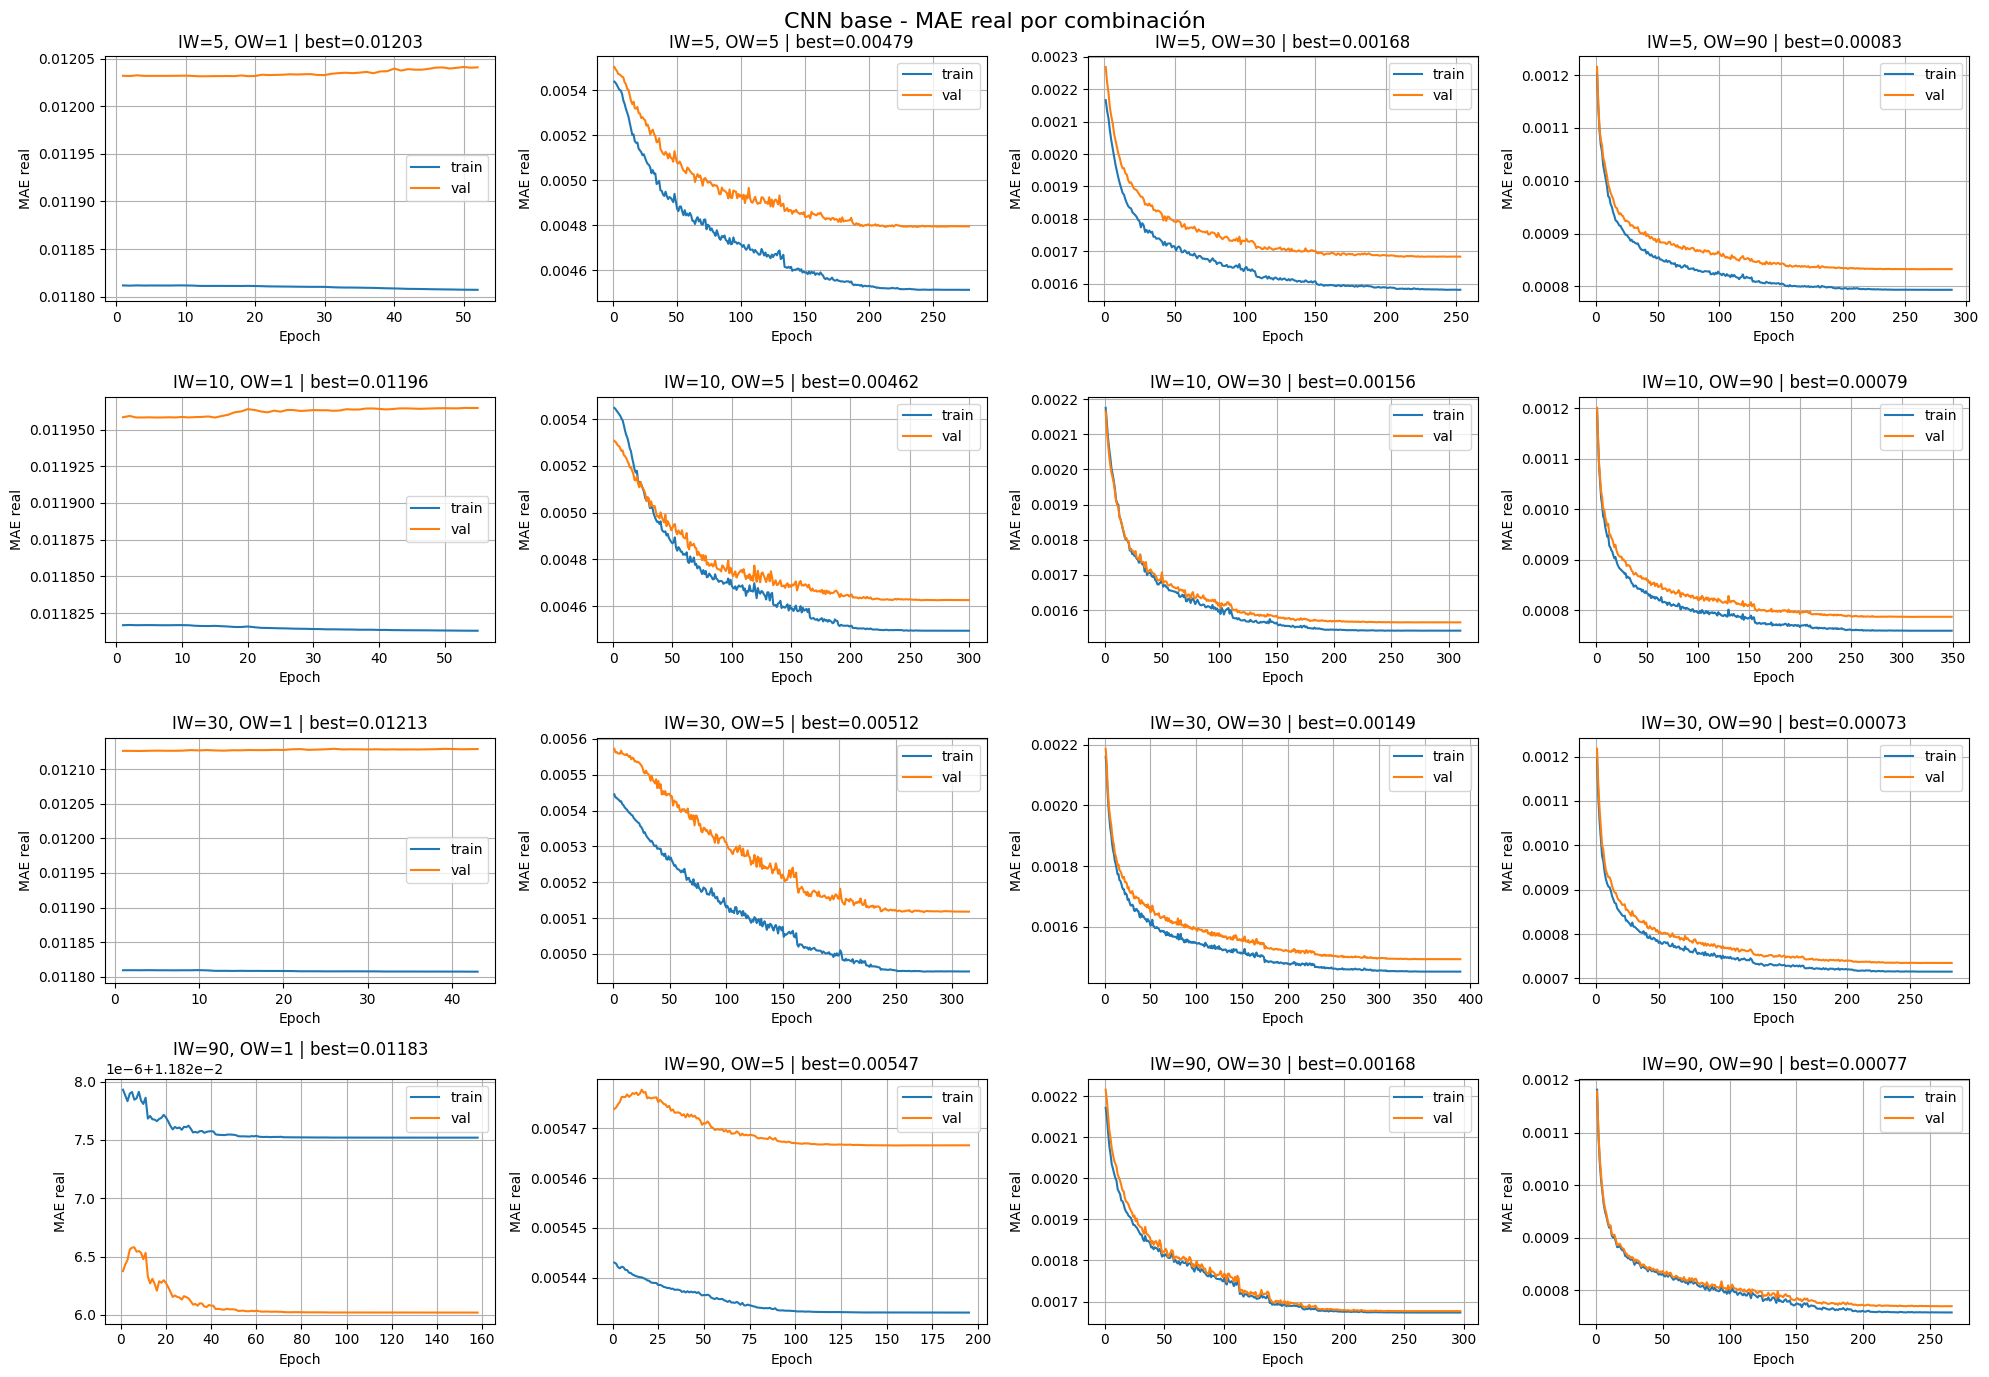

,experiment_name,input_window,output_window,kernel_size,epochs,batch_size,n_params,best_epoch,best_val_mae_real,final_val_mae_real,train_mae_real,val_mae_real,test_mae_real
0,cnn_iw_30_ow_90,30,90,3,283,64,9527,243,0.000735,0.000735,0.000715,0.000735,0.001931
1,cnn_iw_90_ow_90,90,90,3,266,64,9527,226,0.000770,0.000770,0.000758,0.000770,0.001611
2,cnn_iw_10_ow_90,10,90,3,349,64,9527,309,0.000786,0.000787,0.000759,0.000786,0.001752
3,cnn_iw_5_ow_90,5,90,3,288,64,9527,261,0.000832,0.000833,0.000794,0.000832,0.001818
4,cnn_iw_30_ow_30,30,30,3,389,64,9527,332,0.001494,0.001494,0.001453,0.001494,0.002633
5,cnn_iw_10_ow_30,10,30,3,310,64,9527,270,0.001565,0.001565,0.001541,0.001565,0.003093
6,cnn_iw_90_ow_30,90,30,3,297,64,9527,245,0.001677,0.001677,0.001673,0.001677,0.003879
7,cnn_iw_5_ow_30,5,30,3,253,64,9527,224,0.001683,0.001684,0.001584,0.001683,0.002638
8,cnn_iw_10_ow_5,10,5,3,300,64,9527,260,0.004625,0.004625,0.004495,0.004625,0.007317
9,cnn_iw_5_ow_5,5,5,3,278,64,9527,213,0.004792,0.004795,0.004513,0.004793,0.006042


In [40]:
input_windows = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

summary_df, cnn_results = run_cnn_grid(
    features=fracdiff_features,
    targets=log_returns,
    input_windows=input_windows,
    output_windows=output_windows,
    filters_1=32,
    filters_2=64,
    dropout_rate=0.1,
    results_dir="../results/cnn_fd_base_aumentado_results",
    epochs=800,
    batch_size=64,
    verbose=1,
    fixed_kernel_size=3,
)

plot_cnn_grid_losses(
    results=cnn_results,
    input_windows=input_windows,
    output_windows=output_windows,
    save_path="../results/cnn_fd_base_aumentado_results/grid_mae_real.png",
)

summary_df

Entrenando cnn_iw_5_ow_1 | kernel=3 | params=9,527
Epoch 1/800
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6895 - val_loss: 0.6697 - learning_rate: 0.0010
Epoch 2/800
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6887 - val_loss: 0.6696 - learning_rate: 0.0010
Epoch 3/800
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6887 - val_loss: 0.6696 - learning_rate: 0.0010
Epoch 4/800
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6887 - val_loss: 0.6696 - learning_rate: 0.0010
Epoch 5/800
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6887 - val_loss: 0.6696 - learning_rate: 0.0010
Epoch 6/800
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6887 - val_loss: 0.6696 - learning_rate: 0.0010
Epoch 7/800
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6887 - val_loss: 0.6696 - learning_rate: 0.0010
Epoch 8/800
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6887 - val_loss: 0.6696 - learning_rate: 0.0010
Epoch 9/800
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 

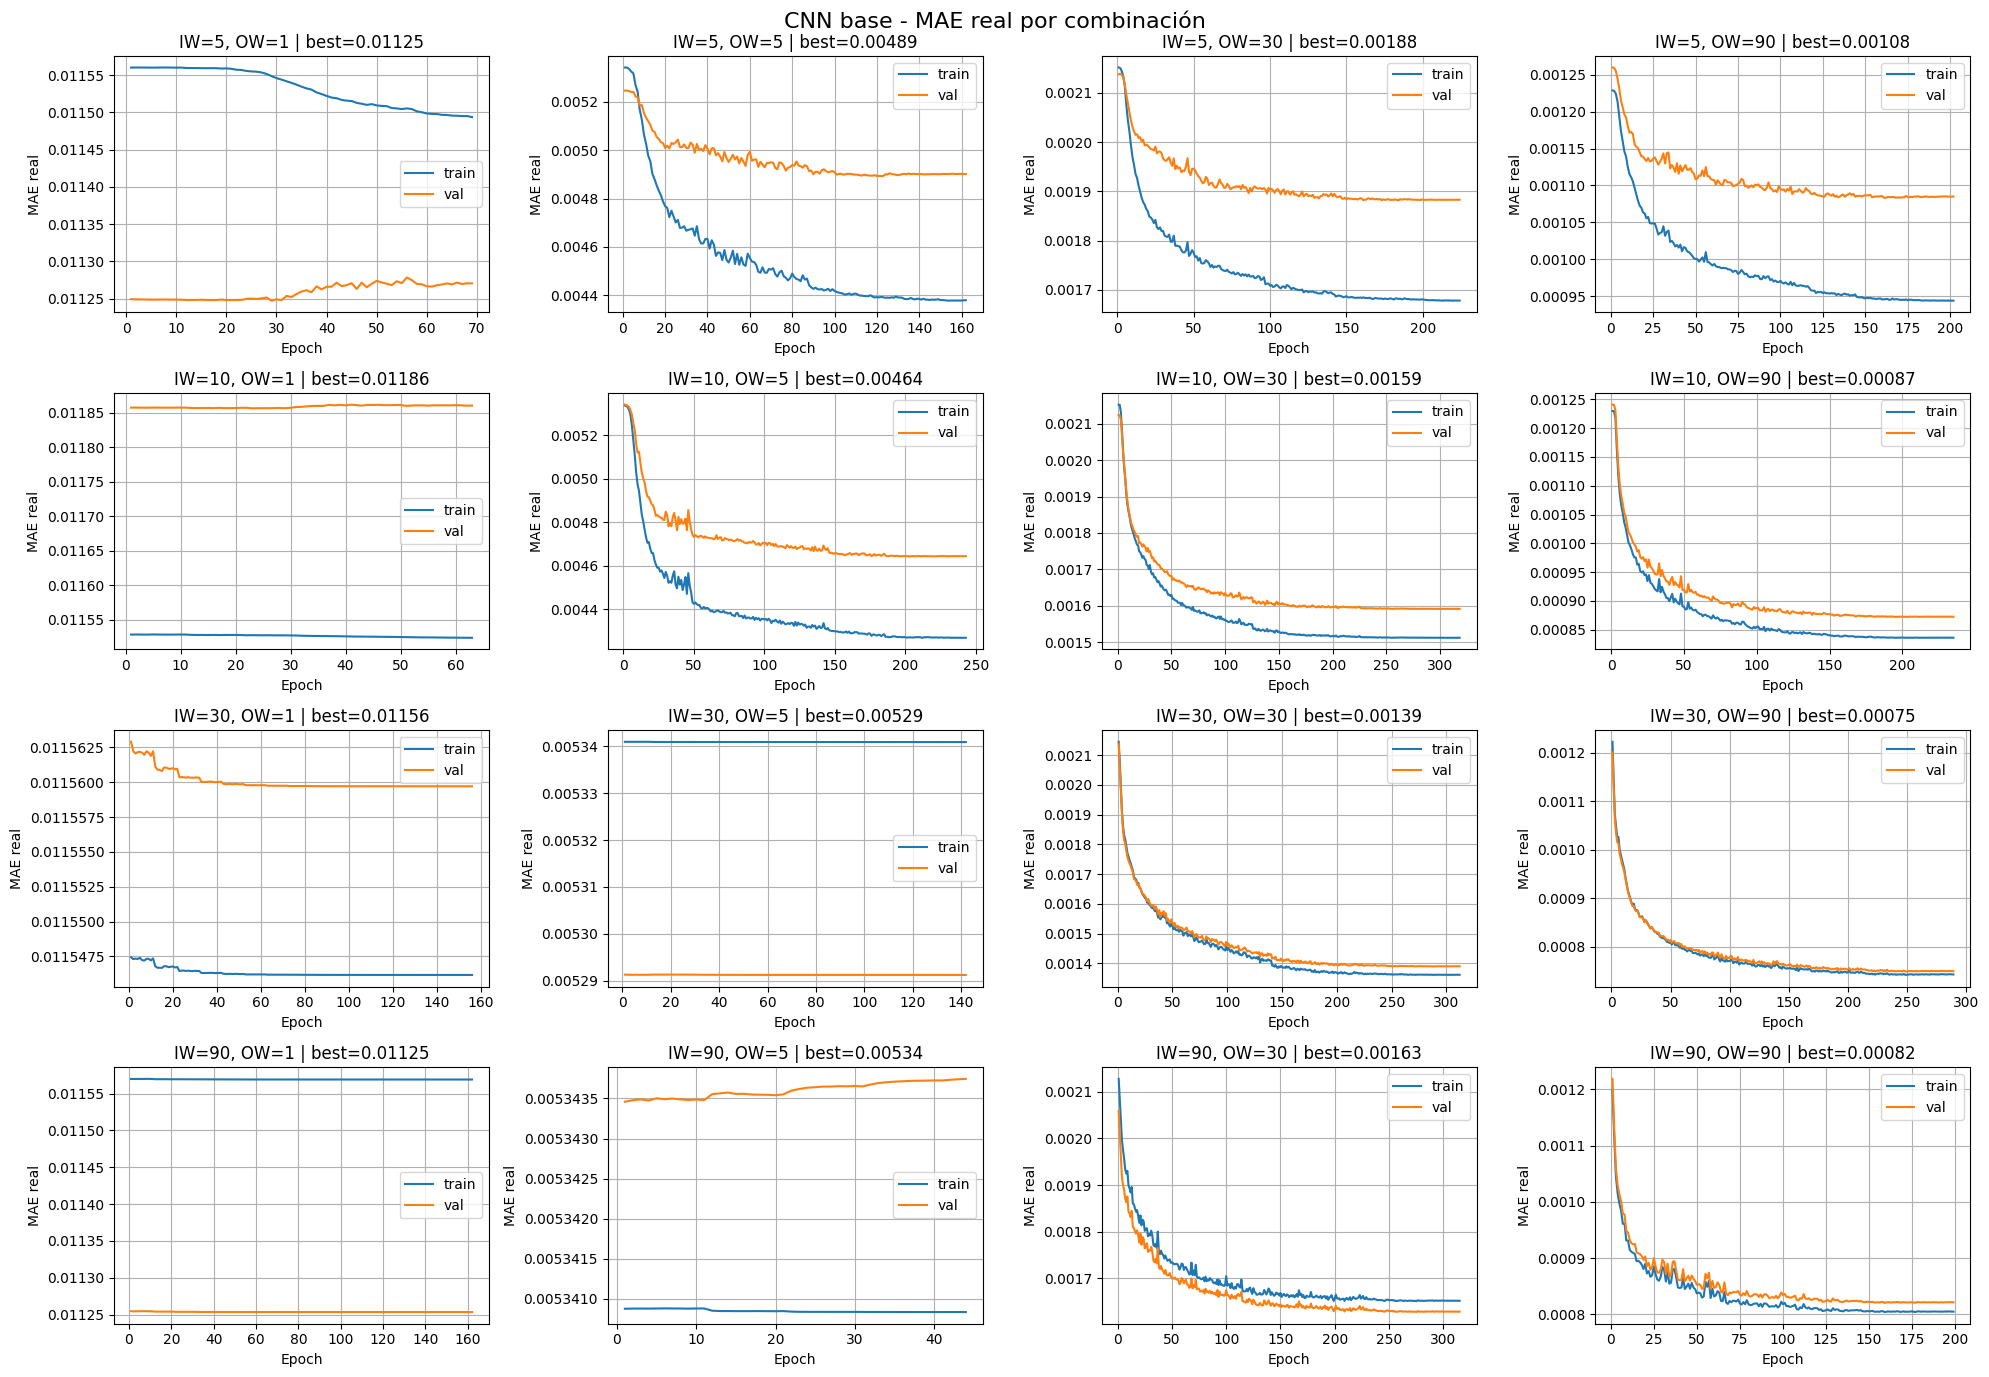

,experiment_name,input_window,output_window,kernel_size,epochs,batch_size,n_params,best_epoch,best_val_mae_real,final_val_mae_real,train_mae_real,val_mae_real,test_mae_real
0,cnn_iw_30_ow_90,30,90,3,289,64,9527,249,0.000749,0.000749,0.000742,0.000749,0.001360
1,cnn_iw_90_ow_90,90,90,3,199,64,9527,159,0.000820,0.000821,0.000804,0.000820,0.001390
2,cnn_iw_10_ow_90,10,90,3,235,64,9527,195,0.000872,0.000873,0.000836,0.000872,0.001373
3,cnn_iw_5_ow_90,5,90,3,202,64,9527,162,0.001083,0.001085,0.000946,0.001083,0.001376
4,cnn_iw_30_ow_30,30,30,3,312,64,9527,272,0.001389,0.001390,0.001361,0.001389,0.002457
5,cnn_iw_10_ow_30,10,30,3,318,64,9527,278,0.001591,0.001591,0.001512,0.001591,0.002458
6,cnn_iw_90_ow_30,90,30,3,315,64,9527,275,0.001627,0.001628,0.001650,0.001627,0.002792
7,cnn_iw_5_ow_30,5,30,3,224,64,9527,184,0.001882,0.001883,0.001682,0.001882,0.002484
8,cnn_iw_10_ow_5,10,5,3,243,64,9527,203,0.004643,0.004645,0.004271,0.004643,0.006113
9,cnn_iw_5_ow_5,5,5,3,162,64,9527,122,0.004893,0.004902,0.004393,0.004893,0.006047


In [41]:
# Con retornos reales como features

input_windows = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

summary_df, cnn_results = run_cnn_grid(
    features=returns,
    targets=returns,
    input_windows=input_windows,
    output_windows=output_windows,
    filters_1=32,
    filters_2=64,
    dropout_rate=0.1,
    results_dir="../results/cnn_base_aumentado_results",
    epochs=800,
    batch_size=64,
    verbose=1,
    fixed_kernel_size=3,
)

plot_cnn_grid_losses(
    results=cnn_results,
    input_windows=input_windows,
    output_windows=output_windows,
    save_path="../results/cnn_base_aumentado_results/grid_mae_real.png",
)

summary_df

Comparamos resultados entre usar los retornos usuales y diferenciación fraccional

In [42]:
# ─────────────────────────────────────────────────────────────
# Carga resultados
# ─────────────────────────────────────────────────────────────

fd_path = Path(
    "../results/cnn_fd_base_aumentado_results/summary_all_experiments.csv"
)

base_path = Path(
    "../results/cnn_base_aumentado_results/summary_all_experiments.csv"
)

fd_df = pd.read_csv(fd_path)
base_df = pd.read_csv(base_path)

# ─────────────────────────────────────────────────────────────
# Selección y renombrado
# ─────────────────────────────────────────────────────────────

fd_df = fd_df[
    [
        "input_window",
        "output_window",
        "test_mae_real",
        "val_mae_real",
        "train_mae_real",
        "best_val_mae_real",
        "best_epoch",
    ]
].copy()

base_df = base_df[
    [
        "input_window",
        "output_window",
        "test_mae_real",
        "val_mae_real",
        "train_mae_real",
        "best_val_mae_real",
        "best_epoch",
    ]
].copy()

fd_df = fd_df.rename(
    columns={
        "test_mae_real": "fd_test_mae",
        "val_mae_real": "fd_val_mae",
        "train_mae_real": "fd_train_mae",
        "best_val_mae_real": "fd_best_val_mae",
        "best_epoch": "fd_best_epoch",
    }
)

base_df = base_df.rename(
    columns={
        "test_mae_real": "base_test_mae",
        "val_mae_real": "base_val_mae",
        "train_mae_real": "base_train_mae",
        "best_val_mae_real": "base_best_val_mae",
        "best_epoch": "base_best_epoch",
    }
)

# ─────────────────────────────────────────────────────────────
# Merge comparativo
# ─────────────────────────────────────────────────────────────

comparison_df = pd.merge(
    fd_df,
    base_df,
    on=["input_window", "output_window"],
    how="inner",
)

# ─────────────────────────────────────────────────────────────
# Métricas comparativas
# ─────────────────────────────────────────────────────────────

comparison_df["diff_test_mae"] = (
    comparison_df["base_test_mae"]
    - comparison_df["fd_test_mae"]
)

comparison_df["diff_val_mae"] = (
    comparison_df["base_val_mae"]
    - comparison_df["fd_val_mae"]
)

comparison_df["winner_test"] = np.where(
    comparison_df["fd_test_mae"]
    < comparison_df["base_test_mae"],
    "FracDiff",
    "Normal Returns",
)

comparison_df["winner_val"] = np.where(
    comparison_df["fd_val_mae"]
    < comparison_df["base_val_mae"],
    "FracDiff",
    "Normal Returns",
)

comparison_df["improvement_test_pct"] = (
    comparison_df["diff_test_mae"]
    / comparison_df["base_test_mae"]
) * 100

comparison_df["improvement_val_pct"] = (
    comparison_df["diff_val_mae"]
    / comparison_df["base_val_mae"]
) * 100

# ─────────────────────────────────────────────────────────────
# Orden final
# ─────────────────────────────────────────────────────────────

comparison_df = comparison_df.sort_values(
    ["output_window", "input_window"]
).reset_index(drop=True)

# ─────────────────────────────────────────────────────────────
# Redondeo visual
# ─────────────────────────────────────────────────────────────

numeric_cols = comparison_df.select_dtypes(
    include=np.number
).columns

comparison_df[numeric_cols] = comparison_df[numeric_cols].round(8)


# ─────────────────────────────────────────────────────────────
# Guardar resultados comparativos
# ─────────────────────────────────────────────────────────────

output_path = Path(
    "../results/cnn_comparison_fd_vs_normal.csv"
)

comparison_df.to_csv(
    output_path,
    index=False,
)

print(f"Comparativa guardada en:\n{output_path.resolve()}")


# ─────────────────────────────────────────────────────────────
# Mostrar tabla
# ─────────────────────────────────────────────────────────────

comparison_df

Comparativa guardada en:
C:\Users\Miriamdbg\Desktop\MIAX\Tareas\Tarea 11_RNN\miax-b3t4\results\cnn_comparison_fd_vs_normal.csv


,input_window,output_window,fd_test_mae,fd_val_mae,fd_train_mae,fd_best_val_mae,fd_best_epoch,base_test_mae,base_val_mae,base_train_mae,base_best_val_mae,base_best_epoch,diff_test_mae,diff_val_mae,winner_test,winner_val,improvement_test_pct,improvement_val_pct
0,5,1,0.011261,0.012031,0.011811,0.012031,12,0.012287,0.011247,0.011549,0.011247,29,0.001027,-0.000784,FracDiff,Normal Returns,8.356823,-6.973574
1,10,1,0.011261,0.011958,0.011816,0.011958,15,0.012299,0.011857,0.011528,0.011857,23,0.001038,-0.000101,FracDiff,Normal Returns,8.441636,-0.854870
2,30,1,0.011255,0.012126,0.011809,0.012126,3,0.012302,0.011560,0.011546,0.011560,152,0.001048,-0.000566,FracDiff,Normal Returns,8.518077,-4.900277
3,90,1,0.011240,0.011826,0.011828,0.011826,158,0.012322,0.011253,0.011569,0.011253,156,0.001082,-0.000573,FracDiff,Normal Returns,8.779745,-5.088836
4,5,5,0.006042,0.004793,0.004513,0.004792,213,0.006047,0.004893,0.004393,0.004893,122,0.000005,0.000100,FracDiff,FracDiff,0.078035,2.053520
5,10,5,0.007317,0.004625,0.004495,0.004625,260,0.006113,0.004643,0.004271,0.004643,203,-0.001204,0.000018,Normal Returns,FracDiff,-19.694356,0.396382
6,30,5,0.005364,0.005116,0.004951,0.005116,275,0.005603,0.005291,0.005341,0.005291,142,0.000239,0.000175,FracDiff,FracDiff,4.261024,3.303189
7,90,5,0.005189,0.005467,0.005433,0.005467,155,0.005614,0.005343,0.005341,0.005343,1,0.000425,-0.000123,FracDiff,Normal Returns,7.565988,-2.303329
8,5,30,0.002638,0.001683,0.001584,0.001683,224,0.002484,0.001882,0.001682,0.001882,184,-0.000154,0.000199,Normal Returns,FracDiff,-6.215712,10.554835
9,10,30,0.003093,0.001565,0.001541,0.001565,270,0.002458,0.001591,0.001512,0.001591,278,-0.000634,0.000026,Normal Returns,FracDiff,-25.807919,1.653089


Pintamos y comparamos también ambas juntas

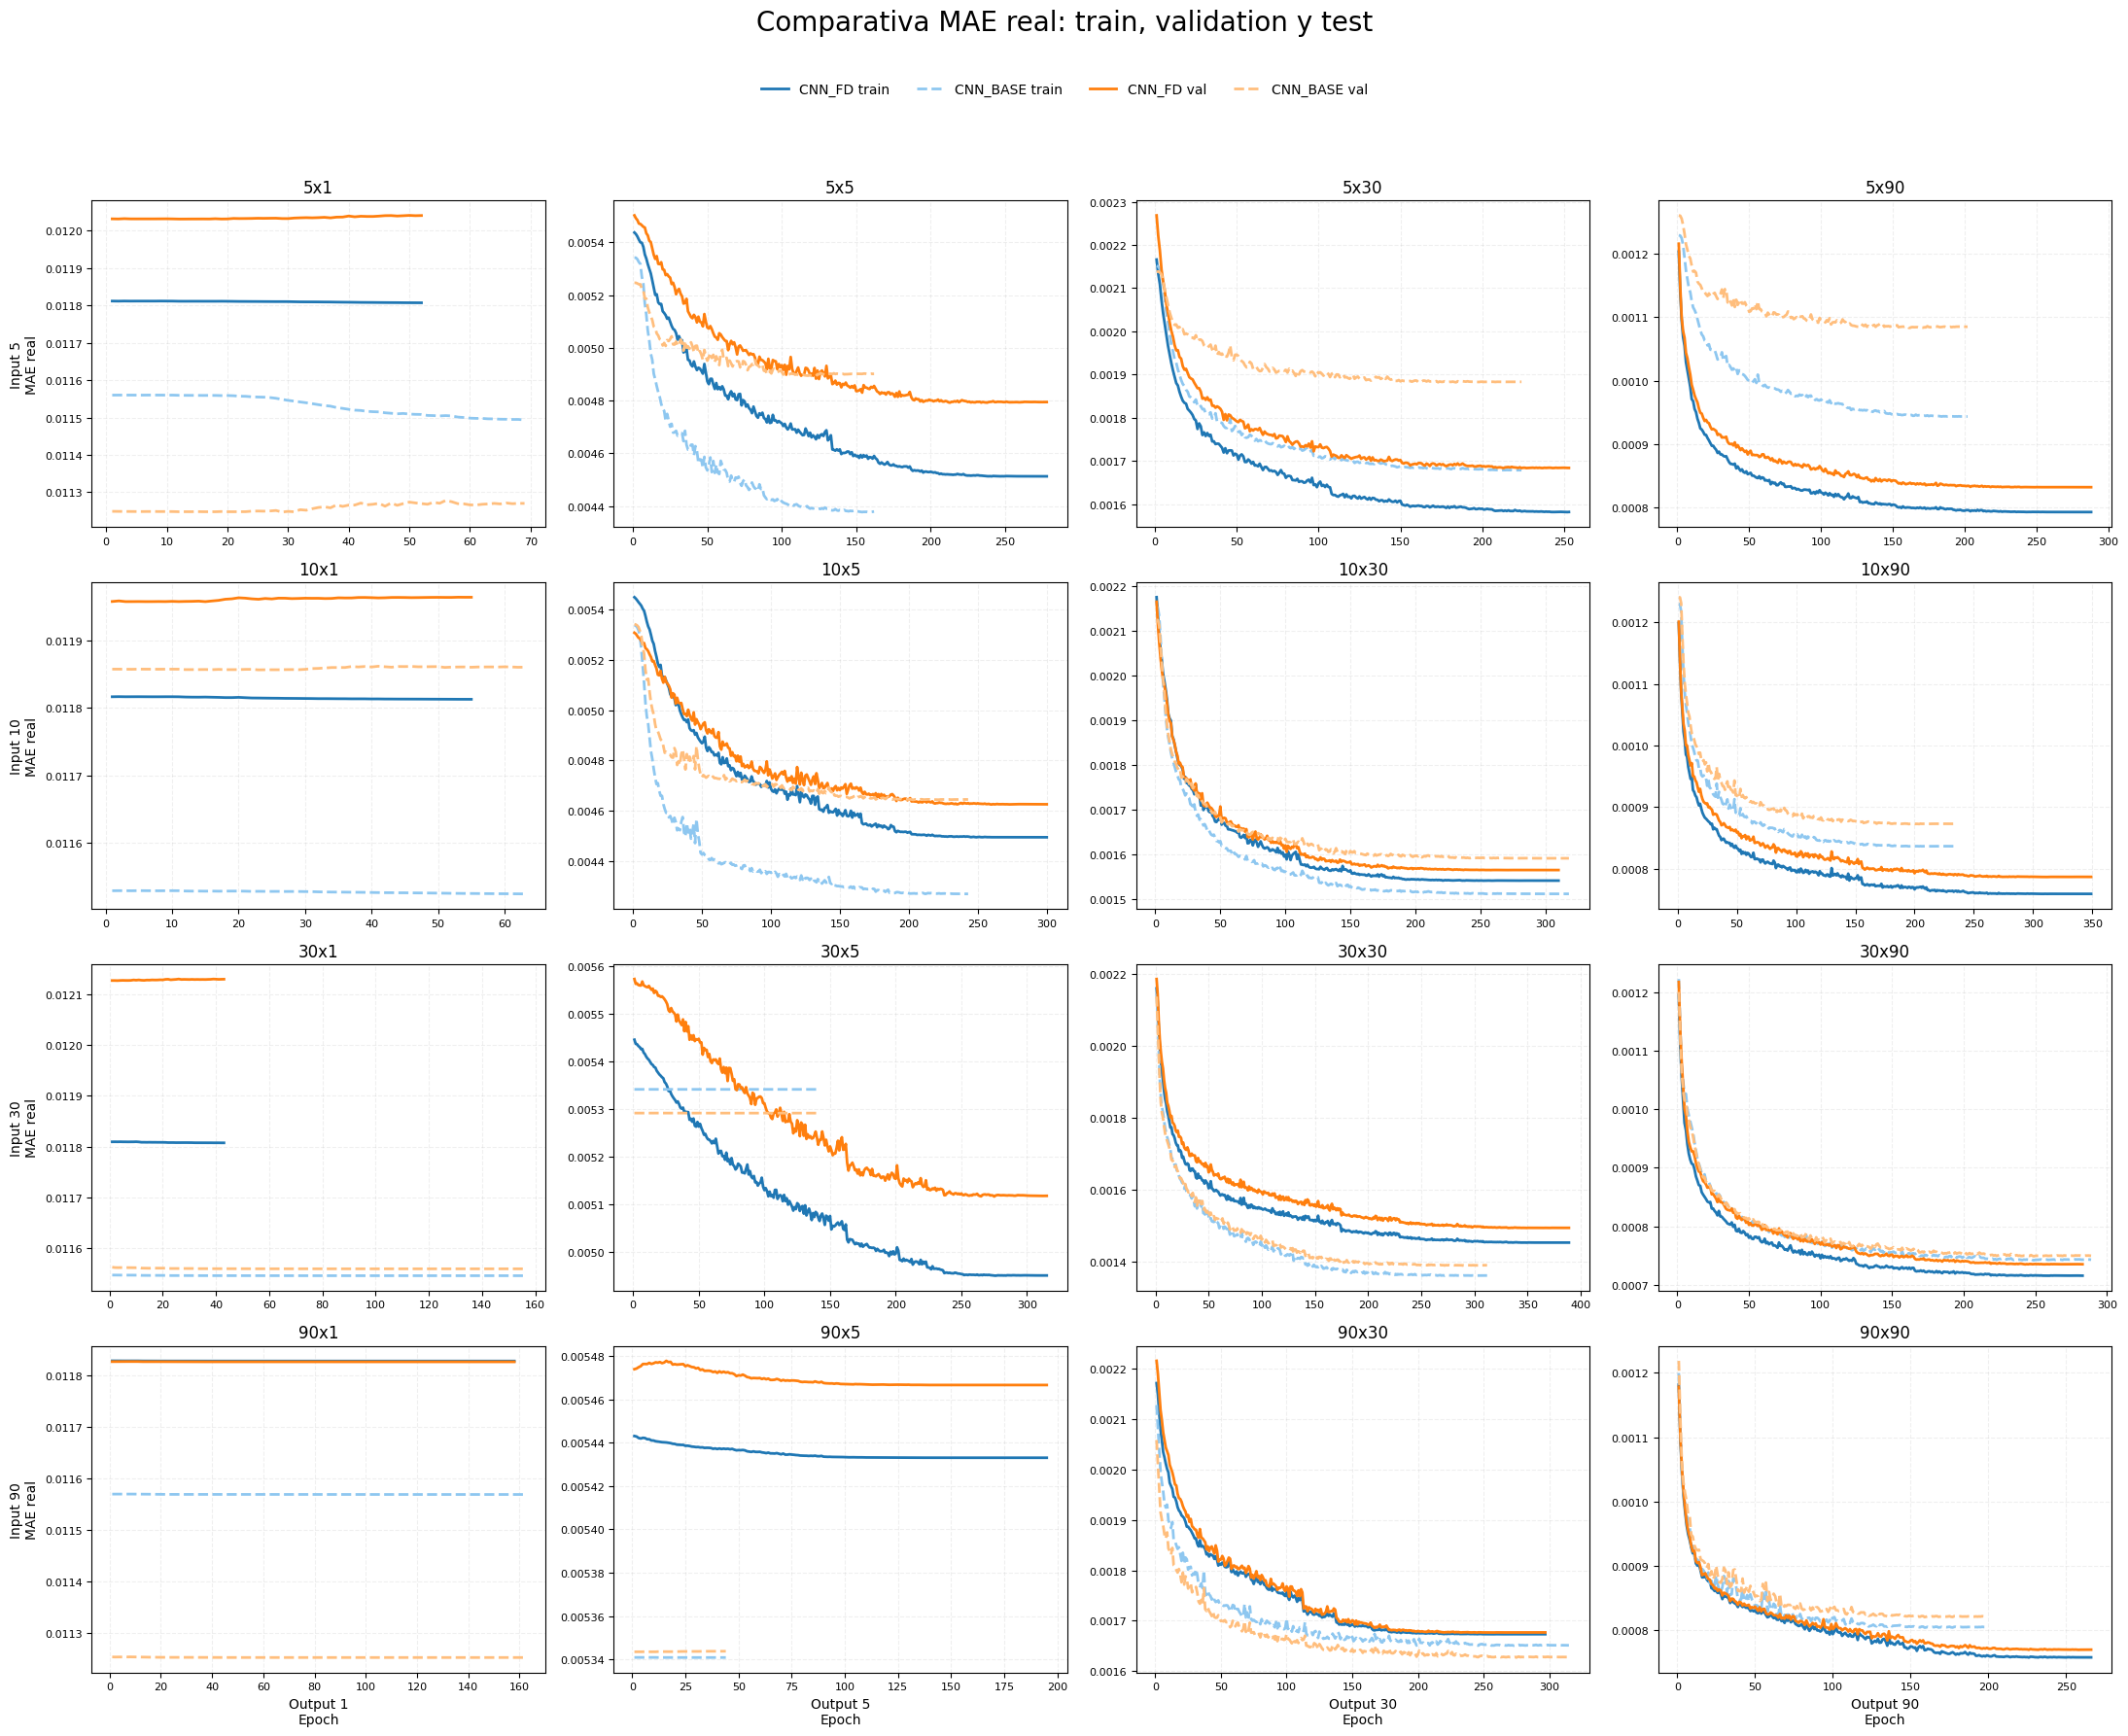

In [57]:


# ── Configuración ──────────────────────────────────────────────
results_dir_a = Path("..") / "results" / "cnn_fd_base_aumentado_results"
results_dir_b = Path("..") / "results" / "cnn_base_aumentado_results"

label_a = "CNN_FD"
label_b = "CNN_BASE"


# ── Estilo ────────────────────────────────────────────────────
colors = {
    "train_dark": "#1f77b4",     # azul fuerte
    "train_light": "#8ec7f0",    # azul claro
    "val_dark": "#ff7f0e",       # naranja fuerte
    "val_light": "#ffbe7d",      # naranja claro
    "test_dark": "#4a4a4a",      # gris oscuro
    "test_light": "#9e9e9e",     # gris claro
}

linestyles = {
    "fd": "-",
    "base": "--",
}


# ── Helpers ────────────────────────────────────────────────────
def load_history(folder: Path) -> pd.DataFrame:
    history_path = folder / "history.csv"

    if not history_path.exists():
        raise FileNotFoundError(f"No existe: {history_path}")

    return pd.read_csv(history_path)


def load_metrics(folder: Path) -> pd.Series:
    metrics_path = folder / "metrics.csv"

    if not metrics_path.exists():
        raise FileNotFoundError(f"No existe: {metrics_path}")

    metrics = pd.read_csv(metrics_path)

    if "test_mae_real" not in metrics.columns:
        raise ValueError(f"No existe la columna test_mae_real en: {metrics_path}")

    return metrics.iloc[0]


# ── Carpetas disponibles ───────────────────────────────────────
folders_a = {
    folder.name: folder
    for folder in results_dir_a.iterdir()
    if folder.is_dir()
}

folders_b = {
    folder.name: folder
    for folder in results_dir_b.iterdir()
    if folder.is_dir()
}


# ── Orden deseado ──────────────────────────────────────────────
input_windows = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

ordered_folders = [
    f"cnn_iw_{input_w}_ow_{output_w}"
    for input_w in input_windows
    for output_w in output_windows
]


# ── Carpetas comunes ordenadas ─────────────────────────────────
common_folders = [
    folder_name
    for folder_name in ordered_folders
    if folder_name in folders_a and folder_name in folders_b
]

if not common_folders:
    raise ValueError("No hay carpetas comunes.")


# ── Grid 4x4 ordenado ─────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=len(input_windows),
    ncols=len(output_windows),
    figsize=(22, 18),
)

axes_map = {
    f"cnn_iw_{input_w}_ow_{output_w}": axes[i, j]
    for i, input_w in enumerate(input_windows)
    for j, output_w in enumerate(output_windows)
}


# ── Plots ──────────────────────────────────────────────────────
for folder_name in common_folders:
    ax = axes_map[folder_name]

    hist_a = load_history(folders_a[folder_name])
    hist_b = load_history(folders_b[folder_name])

    metrics_a = load_metrics(folders_a[folder_name])
    metrics_b = load_metrics(folders_b[folder_name])

    # ==========================================================
    # TRAIN
    # ==========================================================
    ax.plot(
        hist_a["epoch"],
        hist_a["mae_train_real"],
        label=f"{label_a} train",
        color=colors["train_dark"],
        linestyle=linestyles["fd"],
        linewidth=2,
    )

    ax.plot(
        hist_b["epoch"],
        hist_b["mae_train_real"],
        label=f"{label_b} train",
        color=colors["train_light"],
        linestyle=linestyles["base"],
        linewidth=2,
    )

    # ==========================================================
    # VALIDATION
    # ==========================================================
    ax.plot(
        hist_a["epoch"],
        hist_a["mae_val_real"],
        label=f"{label_a} val",
        color=colors["val_dark"],
        linestyle=linestyles["fd"],
        linewidth=2,
    )

    ax.plot(
        hist_b["epoch"],
        hist_b["mae_val_real"],
        label=f"{label_b} val",
        color=colors["val_light"],
        linestyle=linestyles["base"],
        linewidth=2,
    )

    # ==========================================================
    # TEST MAE REAL
    # ==========================================================
    #test_a = float(metrics_a["test_mae_real"])
    #test_b = float(metrics_b["test_mae_real"])

    #ax.axhline(
    #    y=test_a,
    #    label=f"{label_a} test",
    #    color=colors["test_dark"],
    #    linestyle=linestyles["fd"],
    #    linewidth=2,
    #    alpha=0.85,
    #)

    #ax.axhline(
    #    y=test_b,
    #    label=f"{label_b} test",
    #    color=colors["test_light"],
    #    linestyle=linestyles["base"],
    #    linewidth=2,
    #    alpha=0.85,
    #)

    # ── Título limpio ─────────────────────────────────────────
    clean_title = folder_name.replace("cnn_iw_", "").replace("_ow_", "x")

    ax.set_title(clean_title, fontsize=12)

    ax.grid(
        True,
        alpha=0.2,
        linestyle="--",
    )

    ax.tick_params(labelsize=8)


# ── Etiquetas de ejes ──────────────────────────────────────────
for i, input_w in enumerate(input_windows):
    axes[i, 0].set_ylabel(
        f"Input {input_w}\nMAE real",
        fontsize=10,
    )

for j, output_w in enumerate(output_windows):
    axes[-1, j].set_xlabel(
        f"Output {output_w}\nEpoch",
        fontsize=10,
    )


# ── Ocultar subplots sin datos ─────────────────────────────────
for folder_name, ax in axes_map.items():
    if folder_name not in common_folders:
        ax.set_visible(False)


# ── Leyenda global ─────────────────────────────────────────────
first_ax = axes_map[common_folders[0]]
handles, labels = first_ax.get_legend_handles_labels()

fig.suptitle(
    "Comparativa MAE real: train, validation y test",
    fontsize=20,
    y=0.99,
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=6,
    frameon=False,
    fontsize=10,
)
output_path = Path("..") / "results" / "comparativa_cnn_df_logreturns.png"
output_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)


# ── Ajuste layout ──────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.925])
plt.show()